# DPCCA: сравнение CPU и CUDA (CuPy)

Для каждой длины создаются несколько связанных сигналов, после чего один и тот же набор
данных обрабатывается на CPU и CUDA. Сравниваются:

- время полного вызова `dpcca`;
- матрицы ковариации `F`;
- матрицы корреляции `R`;
- матрицы частной корреляции `P`.

In [1]:
from pathlib import Path
from time import perf_counter
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cupy as cp
from scipy import stats
from matplotlib.patches import Patch
from visualization_toolkit.plots.boxplot import boxplot
from visualization_toolkit.styles.boxplot import (
    boxprops_filled,
    boxprops_filled_hatched,
)

current_dir = Path.cwd().resolve()
project_dir = None
for candidate in [current_dir, *current_dir.parents]:
    if (candidate / "StatTools").exists():
        project_dir = candidate
        break

if project_dir is None:
    raise RuntimeError("Не удалось найти корень проекта с папкой StatTools")

if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))

from StatTools.analysis.dpcca import dpcca

print("Project:", project_dir)
print("NumPy:", np.__version__)
print("CuPy:", cp.__version__)


Project: D:\Python\FluctuationAnalysisTools
NumPy: 2.5.3
CuPy: 14.2.0


## Параметры эксперимента

In [2]:
SIZES = [1_000, 10_000, 100_000, 1_000_000]
N_SIGNALS = 3
REPEATS = 15
PD = 2
STEP = 0.5
N_INTEGRAL = 1
BASE_S_VALUES = [16, 32, 64, 128, 256, 512]
RTOL = 1e-7
ATOL = 1e-10

print("Sizes:", SIZES)
print("Signals:", N_SIGNALS)
print("Repeats:", REPEATS)

Sizes: [1000, 10000, 100000, 1000000]
Signals: 3
Repeats: 15


## Генерация нескольких входных сигналов

Первый случайный ряд используется как общая компонента. К нему добавляется независимый шум.

In [3]:
def make_signals(length, n_signals, rng):
    common = rng.standard_normal(length)
    signals = []

    for _ in range(n_signals):
        noise = rng.standard_normal(length)
        signals.append(0.7 * common + 0.3 * noise)

    return np.vstack(signals)


def scales_for_length(length):
    return [s for s in BASE_S_VALUES if s < length]

example = make_signals(1024, N_SIGNALS, np.random.default_rng(42))
print("Input shape:", example.shape)

Input shape: (3, 1024)


## Измерение времени

Измеряется полный вызов DFA, включая передачу данных CPU–GPU.

In [4]:
def measure_dpcca(data, backend, s_values):
    if backend == "cuda":
        cp.cuda.runtime.deviceSynchronize()

    start = perf_counter()
    p, r, f, used_s = dpcca(
        data,
        pd=PD,
        step=STEP,
        s=s_values,
        n_integral=N_INTEGRAL,
        processes=1,
        backend=backend,
    )

    if backend == "cuda":
        cp.cuda.runtime.deviceSynchronize()

    elapsed = perf_counter() - start
    return elapsed, p, r, f, used_s

## Параметры


In [5]:
gpu_name = cp.cuda.runtime.getDeviceProperties(cp.cuda.Device().id)["name"]
if isinstance(gpu_name, bytes):
    gpu_name = gpu_name.decode()

parameters = {
    "sizes": SIZES,
    "n_signals": N_SIGNALS,
    "repeats": REPEATS,
    "pd": PD,
    "step": STEP,
    "n_integral": N_INTEGRAL,
    "base_s_values": BASE_S_VALUES,
    "rtol": RTOL,
    "atol": ATOL,
    "processes": 1,
    "signal": "correlated Gaussian time series",
    "dtype": "float64",
    "gpu": gpu_name,
    "python": sys.version,
    "numpy": np.__version__,
    "cupy": cp.__version__,
}

print("GPU:", gpu_name)
display(pd.Series(parameters, name="value").to_frame())


GPU: NVIDIA GeForce RTX 5080


,value
sizes,"[1000, 10000, 100000, 1000000]"
n_signals,3
repeats,15
pd,2
step,0.5
n_integral,1
base_s_values,"[16, 32, 64, 128, 256, 512]"
rtol,0.0
atol,0.0
processes,1


## Запуск эксперимента и результаты

Для каждой длины создаётся один набор из нескольких сигналов.
Перед серией измерений оба backend прогреваются один раз.

In [6]:
rng = np.random.default_rng(42)

signals = {}
dpcca_results = {}
records = []

for length in SIZES:
    data = make_signals(length, N_SIGNALS, rng)
    signals[length] = data
    s_values = scales_for_length(length)

    print(f"\nLength = {length}, shape = {data.shape}, S = {s_values}")

    measure_dpcca(data, "cpu", s_values)
    measure_dpcca(data, "cuda", s_values)

    for repeat in range(1, REPEATS + 1):
        cpu_time, p_cpu, r_cpu, f_cpu, s_cpu = measure_dpcca(
            data, "cpu", s_values
        )
        cuda_time, p_cuda, r_cuda, f_cuda, s_cuda = measure_dpcca(
            data, "cuda", s_values
        )

        np.testing.assert_array_equal(np.asarray(s_cuda), np.asarray(s_cpu))
        np.testing.assert_allclose(f_cuda, f_cpu, rtol=RTOL, atol=ATOL)
        np.testing.assert_allclose(r_cuda, r_cpu, rtol=RTOL, atol=ATOL)
        np.testing.assert_allclose(p_cuda, p_cpu, rtol=RTOL, atol=ATOL)

        dpcca_results[(length, repeat)] = {
            "s_cpu": np.asarray(s_cpu),
            "p_cpu": p_cpu,
            "r_cpu": r_cpu,
            "f_cpu": f_cpu,
            "s_cuda": np.asarray(s_cuda),
            "p_cuda": p_cuda,
            "r_cuda": r_cuda,
            "f_cuda": f_cuda,
        }

        records.append({
            "length": length,
            "n_signals": N_SIGNALS,
            "repeat": repeat,
            "cpu_seconds": cpu_time,
            "cuda_seconds": cuda_time,
            "speedup": cpu_time / cuda_time,
            "max_abs_diff_F": float(np.max(np.abs(f_cuda - f_cpu))),
            "max_abs_diff_R": float(np.max(np.abs(r_cuda - r_cpu))),
            "max_abs_diff_P": float(np.max(np.abs(p_cuda - p_cpu))),
        })

        print(
            f"  repeat {repeat}: CPU={cpu_time:.4f}s, "
            f"CUDA={cuda_time:.4f}s, speedup={cpu_time / cuda_time:.2f}x"
        )

results = pd.DataFrame(records)
display(results)



Length = 1000, shape = (3, 1000), S = [16, 32, 64, 128, 256, 512]
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
  repeat 1: CPU=0.0012s, CUDA=0.0166s, speedup=0.07x
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
  repeat 2: CPU=0.0009s, CUDA=0.0160s, speedup=0.05x
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
  repeat 3: CPU=0.0009s, CUDA=0.0168s, speedup=0.05x
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
	DPCAA warning: only following S values are in use: [16, 32, 64, 128]
  repeat 4: CPU=0.0009s, CUDA=0.0160s, speedup=0.06x
	DPCAA warning: only 

,length,n_signals,repeat,cpu_seconds,cuda_seconds,speedup,max_abs_diff_F,max_abs_diff_R,max_abs_diff_P
0,1000,3,1,0.001168,0.016630,0.070216,1.332268e-15,2.220446e-16,1.110223e-15
1,1000,3,2,0.000873,0.015985,0.054608,1.332268e-15,2.220446e-16,1.110223e-15
2,1000,3,3,0.000868,0.016828,0.051563,1.332268e-15,2.220446e-16,1.110223e-15
3,1000,3,4,0.000891,0.015993,0.055707,1.332268e-15,2.220446e-16,1.110223e-15
4,1000,3,5,0.000881,0.017180,0.051264,1.332268e-15,2.220446e-16,1.110223e-15
5,1000,3,6,0.000846,0.018168,0.046560,1.332268e-15,2.220446e-16,1.110223e-15
6,1000,3,7,0.000941,0.019219,0.048984,1.332268e-15,2.220446e-16,1.110223e-15
7,1000,3,8,0.000918,0.032257,0.028465,1.332268e-15,2.220446e-16,1.110223e-15
8,1000,3,9,0.000914,0.018618,0.049065,1.332268e-15,2.220446e-16,1.110223e-15
9,1000,3,10,0.000874,0.017655,0.049503,1.332268e-15,2.220446e-16,1.110223e-15


## Сводные результаты

`speedup > 1` означает, что CUDA быстрее CPU.

In [7]:
times = results.melt(
    id_vars=["length", "n_signals", "repeat"],
    value_vars=["cpu_seconds", "cuda_seconds"],
    var_name="backend",
    value_name="seconds",
)
times["backend"] = times["backend"].map({
    "cpu_seconds": "CPU",
    "cuda_seconds": "CUDA",
})

time_summary = times.groupby(["length", "backend"])["seconds"].agg(
    ["count", "mean", "median", "std", "min", "max"],
)
comparison = results.groupby("length").agg(
    median_speedup=("speedup", "median"),
    max_abs_diff_F=("max_abs_diff_F", "max"),
    max_abs_diff_R=("max_abs_diff_R", "max"),
    max_abs_diff_P=("max_abs_diff_P", "max"),
)

display(time_summary)
display(comparison)


count      mean    median       std       min       max
length  backend                                                         
1000    CPU         15  0.000907  0.000888  0.000076  0.000846  0.001168
        CUDA        15  0.018251  0.017180  0.004011  0.015907  0.032257
10000   CPU         15  0.006961  0.007210  0.001535  0.005147  0.009415
        CUDA        15  0.028464  0.028232  0.003290  0.024766  0.039208
100000  CPU         15  0.097860  0.098578  0.002868  0.093260  0.101906
        CUDA        15  0.027810  0.026990  0.002824  0.025929  0.037515
1000000 CPU         15  0.815876  0.816997  0.007898  0.800439  0.831701
        CUDA        15  0.055864  0.038360  0.036845  0.035815  0.138214

,median_speedup,max_abs_diff_F,max_abs_diff_R,max_abs_diff_P
length,,,,
1000,0.051264,1.332268e-15,2.220446e-16,1.110223e-15
10000,0.249127,1.065814e-14,4.440892e-16,2.553513e-15
100000,3.590852,1.243450e-14,4.440892e-16,2.275957e-15
1000000,21.393559,1.953993e-14,3.330669e-16,1.609823e-15


## Графики времени и ускорения

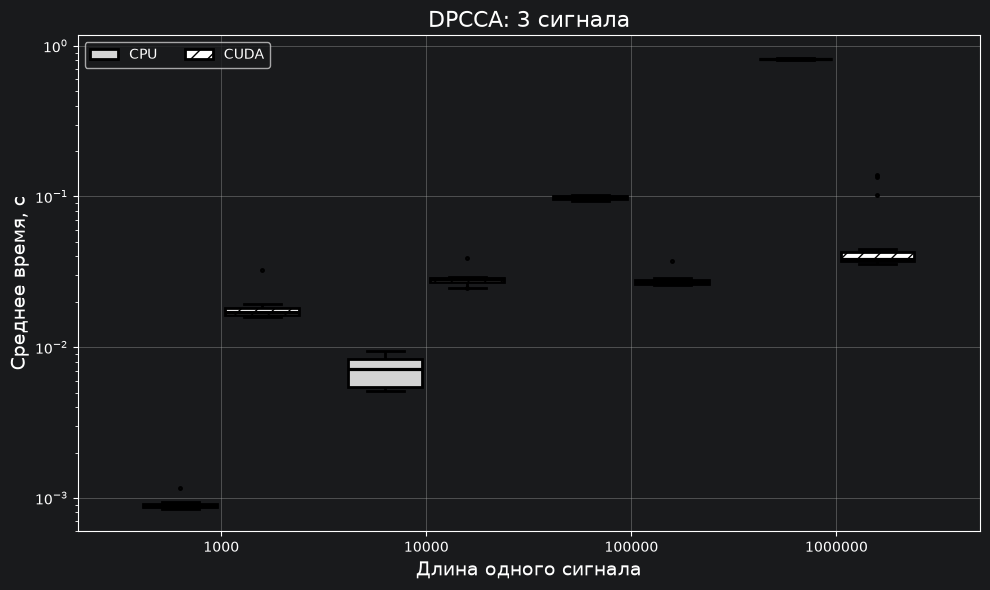

In [8]:
times["backend"] = times["backend"].astype(object)

styles = {
    "CPU": boxprops_filled(),
    "CUDA": boxprops_filled_hatched(hatch="//"),
}

fig, axes = boxplot(
    data=times,
    x="length",
    y="seconds",
    hue="backend",
    styles=styles,
    logy=True,
    x_label="Длина одного сигнала",
    y_label="Среднее время, с",
    title=f"DPCCA: {N_SIGNALS} сигнала",
    axes_fontsize=14,
    title_fontsize=16,
    fig_size=(10, 6),
)

for legend in list(fig.legends):
    legend.remove()

handles = [
    Patch(label=backend, **style["boxprops"])
    for backend, style in styles.items()
]
axes[0].legend(handles=handles, loc="upper left", ncol=2, fontsize=10)
fig.tight_layout()
plt.show()
plt.close(fig)


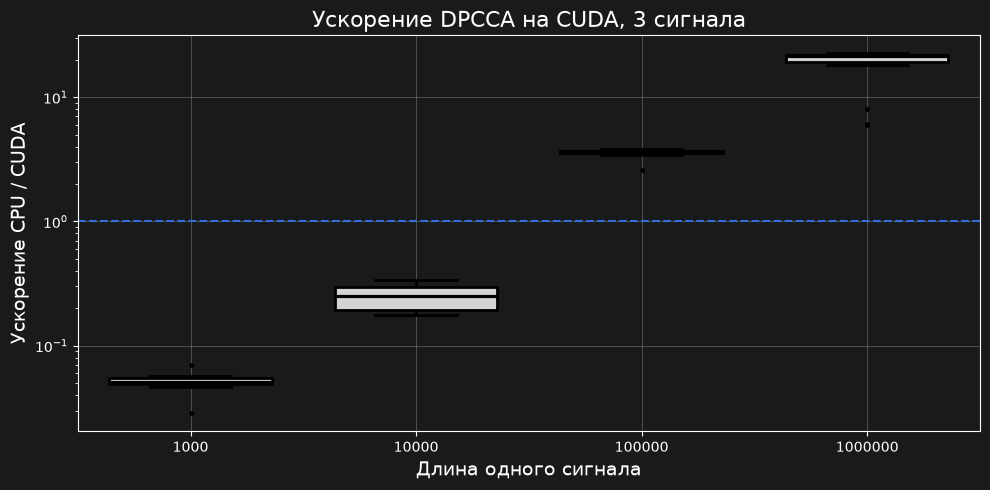

In [9]:
fig, axes = boxplot(
    data=results,
    x="length",
    y="speedup",
    styles={None: boxprops_filled()},
    logy=True,
    x_label="Длина одного сигнала",
    y_label="Ускорение CPU / CUDA",
    title=f"Ускорение DPCCA на CUDA, {N_SIGNALS} сигнала",
    axes_fontsize=14,
    title_fontsize=16,
    fig_size=(10, 5),
)
axes[0].axhline(1.0, linestyle="--")
fig.tight_layout()
plt.show()
plt.close(fig)
